In [1]:
import numpy as np
from NSC import solve_Cosmo as NSC

import tqdm as tqdm 

import matplotlib.pyplot as plt

In [36]:
a1 = NSC.Track_all_lam(1e12, d_decay=6, lam=1e14 )

final temp above BBN 4.738e+07



In [37]:
rhor1, rhoQ1, srad1, Temp1, lu , sV, rhoQ_af1, rhor_af1, ulfin = a1

Text(0.5, 0, '$1/T\\,\\,\\left[{\\rm GeV}^{-1}\\right]$')

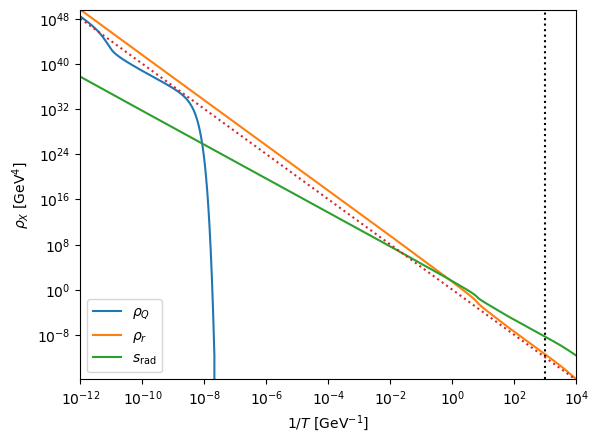

In [38]:
plt.loglog(1/Temp1,  rhoQ1, label=r'$\rho_Q$')

plt.loglog(1/Temp1, rhor1, label=r'$\rho_r$')

plt.loglog(1/Temp1, srad1, label=r'$s_{\rm rad}$')

plt.axvline(1/1e-3, ls=':', color='k')

plt.ylim(np.min(rhor1), np.max(rhor1))
plt.xlim(1/Temp1[0], 1/Temp1[-1])

plt.plot(1/Temp1, 1e0*Temp1**4, ls=':')

plt.legend()
plt.ylabel(r'$\rho_X\,\,\left[{\rm GeV}^{4}\right]$')
plt.xlabel(r'$1/T\,\,\left[{\rm GeV}^{-1}\right]$')

In [39]:
RDlu, RDTEMP, lH = np.genfromtxt("/home/andrew/Documents/Tools/MiMeS/UserSpace/InputExamples/RDinput.dat", unpack=True)

In [40]:
Huba1 = [np.sqrt((1)/(3*(2.4e18**2)))*np.sqrt(rhoQ_af1[i] + rhor_af1[i] ) for i in range(len(lu))]

In [41]:
offset = len(rhor1) - len(lu)

In [42]:
offset

423

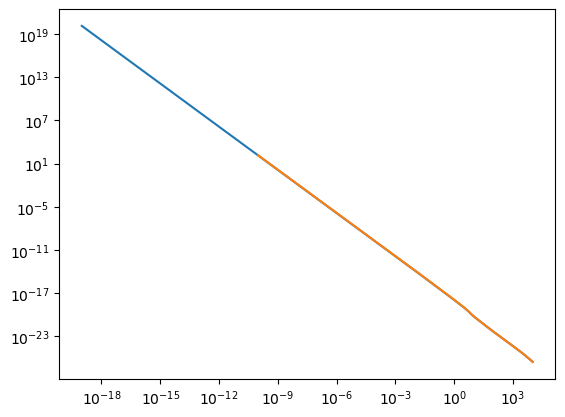

In [43]:
plt.loglog(1/RDTEMP, np.exp(lH))
plt.loglog(1/Temp1[offset:], Huba1)


In [44]:
np.min(RDTEMP)

0.00010061504421788868

In [45]:
#plt.loglog(1/RDTEMP, np.exp(lH))
#plt.loglog(1/Temp1, np.exp(lH)/Huba1)

- Can track the total entropy difference $s_{\rm rad}a^3$ where $a$ is the scale factor. 

- Below I only have the plot for the period of decay, due to the way the solver works. 

Text(0.5, 0, '$\\log(a/a_i)$')

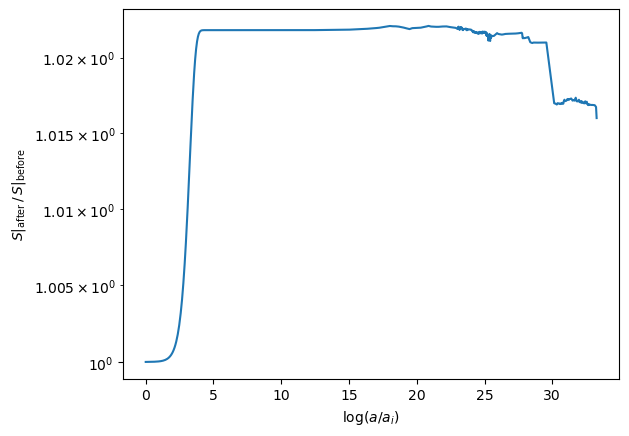

In [46]:
plt.semilogy(lu, sV/sV[0])


plt.ylabel(r'$S\vert_{\rm after} \,/\, S\vert_{\rm before}\,\,$')



plt.xlabel(r'$\log(a/a_i)$')

- I also have the densities in this region so check their behaviour

Text(0.5, 0, '$\\log(a/a_i)$')

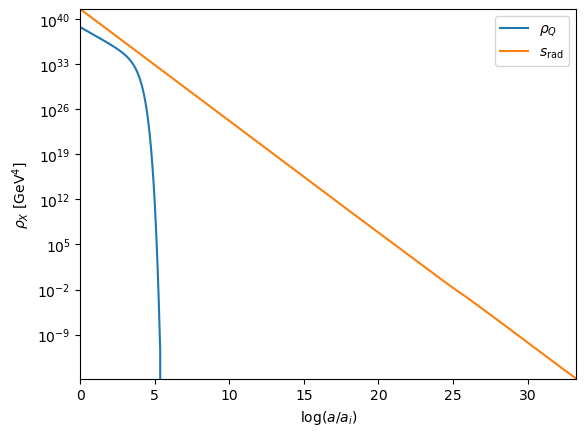

In [47]:
plt.semilogy(lu, rhoQ_af1, label=r'$\rho_Q$')
plt.semilogy(lu, rhor_af1, label=r'$s_{\rm rad}$')


plt.ylim(np.min(rhor_af1), np.max(rhor_af1))
plt.xlim(lu[0], lu[-1])

plt.legend()
plt.ylabel(r'$\rho_X\,\,\left[{\rm GeV}^{4}\right]$')
plt.xlabel(r'$\log(a/a_i)$')

- For creating the GW spectrum we don't need all this information, we just call the following. 

In [48]:
?NSC.GW_input_lam

Signature: NSC.GW_input_lam(mQ_p, d_decay=6, lam=1.22e+19, ratio_Ti=1.0)
Docstring: return sRad_volume_aFO[-1]/sRad_volume_aFO[0] , Teq, Tdec
File:      ~/Documents/Tools/NSC/NSC/solve_Cosmo.py
Type:      function

In [49]:
invdil, Teq, Tdec = NSC.GW_input_lam(1e12, 6, 1e14)

print(invdil, Teq, Tdec)

1.0218629685602092 0.0 0.0


- I think you have enough information to create the GW signal here, but I will show an example here.  

In [50]:
import GW_spectrum as GW

In [51]:
a0=1 
h= 0.7 
Hub0 = h * (9.777)**(-1) * 3.168e-17
TRH = 1e16
nT = 0.5 


fspace = np.logspace(-10, 10, 100)
k_values = 2*np.pi*fspace

In [52]:
GW_results = []
if Teq == 0:
    # If Teq == 0, return the result of OmegaGW the Standard cosmology for all k values
    for k in k_values:
        GW_results.append(GW.OmegaGW(k, TRH, nT, h=h))
else:
    # Compute OmegaGW for each k with an intermediate matter domination
    for k in k_values:
        result = (
            (1/12) * (k / (a0 * Hub0))**2
            * GW.T2TIMD_dil(k, Tdec, Teq, TRH, invdil)
            * GW.PT_func(k, nT)
        )
        GW_results.append(result)



Text(0.5, 0, '$f\\,\\left[{\\rm Hz}\\right]$')

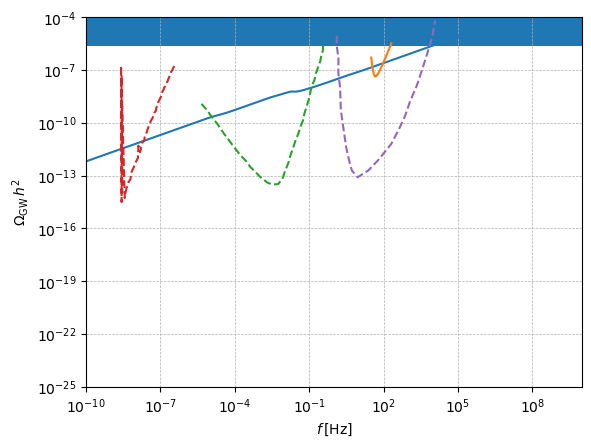

In [53]:
fig, ax =  plt.subplots()


plt.loglog(fspace, GW_results)


plt.loglog(10**GW.LIGOf, 10**GW.LIGO_OmGW)

plt.loglog(10**GW.LISAf, 10**GW.LISA_OmGW, ls='--')
plt.loglog(10**GW.SKA20f, 10**GW.SKA20_om, ls='--')
plt.loglog(GW.ETf, GW.ET_om, ls='--')

plt.axhspan(0.4*5.6e-6, 1)


plt.xlim(xmin=1e-10, xmax=1e10)
plt.ylim(1e-25, 1e-4)
ax.grid(which='both', linestyle='--', linewidth=0.5)

plt.ylabel(r'$\Omega_{\rm GW}\, h^2$')
plt.xlabel(r'$f\,\left[{\rm Hz}\right]$')

- Can do a scan of $\Lambda$ and $m_Q$ to find the GW overproduction 

In [54]:
lam1D = np.geomspace(1e14, 5e19, 50)
mQ1D = np.geomspace(1e8, 1e12, 50)

MQ2D, LAM2D = np.meshgrid(mQ1D, lam1D)

In [55]:
tqdm

<module 'tqdm' from '/home/andrew/anaconda3/lib/python3.11/site-packages/tqdm/__init__.py'>

In [56]:

omGWmax_d6 = np.zeros(np.shape(MQ2D))

for i in tqdm.tqdm(range(len(MQ2D[:,0]))):
    for j in range(len(MQ2D[0,:])):
        tmp_mQ = MQ2D[i,j]
        tmp_Lam = LAM2D[i,j]
        tmp_GW = GW.OmegaGW_preferred_axion_lam(2*np.pi*fspace, tmp_mQ, 
                                                TRH, nT, 6, tmp_Lam)
        omGWmax_d6[i,j] = np.max(tmp_GW)

  0%|          | 0/50 [00:00<?, ?it/s]

 94%|█████████▍| 47/50 [6:49:57<41:14, 824.82s/it]   /home/andrew/Documents/Tools/NSC/NSC/solve_Cosmo.py:346: RuntimeWarning: overflow encountered in scalar power
  a = [10.**(aexp[0])]
/home/andrew/Documents/Tools/NSC/NSC/solve_Cosmo.py:358: RuntimeWarning: invalid value encountered in scalar add
  return [A + B + C - D*t]
/home/andrew/Documents/Tools/NSC/NSC/solve_Cosmo.py:351: RuntimeWarning: overflow encountered in scalar multiply
  B = a[0] * rQi * np.sqrt(SC.GCF * (a[0] * rQi + rRadi))
 98%|█████████▊| 49/50 [14:49:01<1:48:27, 6507.25s/it]/home/andrew/Documents/Tools/NSC/NSC/solve_Cosmo.py:352: RuntimeWarning: overflow encountered in scalar multiply
  C = 2. * rRadi * (np.sqrt(SC.GCF*(ain * rQi + rRadi)) - np.sqrt(SC.GCF*(a[0]*rQi + rRadi)))
100%|██████████| 50/50 [15:01:52<00:00, 1082.26s/it]  


In [57]:
omGWmax_d6

array([[4.28782053e-05, 4.57305564e-05, 4.66998749e-05, ...,
        3.77008106e-04, 3.77008106e-04, 3.77008106e-04],
       [2.27680804e-05, 2.51070835e-05, 2.73347556e-05, ...,
        3.77008106e-04, 3.77008106e-04, 3.77008106e-04],
       [1.16692190e-05, 1.29260837e-05, 1.43560936e-05, ...,
        3.77008106e-04, 3.77008106e-04, 3.77008106e-04],
       ...,
       [3.97932236e-21, 4.64410630e-21, 5.45638948e-21, ...,
        4.74009726e-13, 5.99275329e-13, 7.58079575e-13],
       [1.79241785e-21, 2.10228485e-21, 2.48234079e-21, ...,
        2.94445467e-13, 4.54295244e-13, 5.75259218e-13],
       [7.86007030e-22, 9.26000168e-22, 1.10008017e-21, ...,
        1.35478407e-13, 2.71884751e-13, 4.34633600e-13]])

Text(0, 0.5, '$\\Lambda\\,\\,\\left[{\\rm GeV}\\right]$')

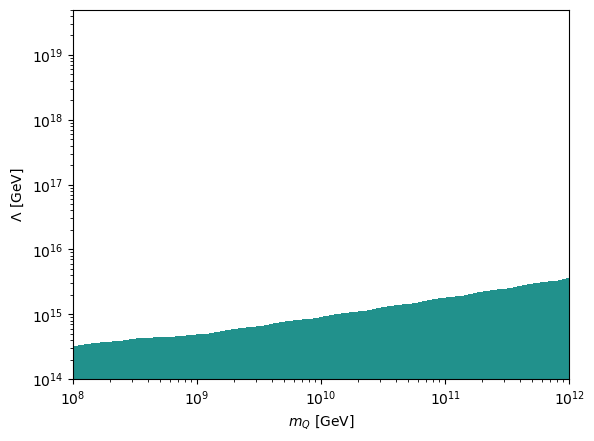

In [58]:
plt.yscale("log")
plt.xscale("log")

plt.contourf(MQ2D, LAM2D, omGWmax_d6, levels=[0.4*5.6e-6, 100])
plt.xlabel(r'$m_Q\,\,\left[{\rm GeV}\right]$')
plt.ylabel(r'$\Lambda\,\,\left[{\rm GeV}\right]$')

In [60]:
np.save('omGWmaxd6_v2.npy', [MQ2D, LAM2D, omGWmax_d6], allow_pickle=True)